# 23CSE301 Machine Learning - Capstone Project
## Classification Track - Machine Predictive Maintenance (Part A)

**Track owner:** _(name - see `docs/team_contributions.md`)_
**Review:** Review 1 - Part A (the five Review 1 algorithms)
**Dataset:** Machine Predictive Maintenance Classification - `predictive_maintenance.csv`
**Source:** https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification

---

### How to read this notebook

Each algorithm has its **own section**: first a short explanation of what it is
and how it works, then the code that builds and trains *that* model on our data,
then its result. Every model uses the same train/test split created in section 3,
which is what makes the comparison tables fair.

Pipeline steps come from `src/`, the same code `scripts/run_all.py` runs, so the
notebook and the scripts cannot drift apart.

**AI assistance:** code scaffolding was AI-generated (see `README.md`,
AI-Assistance Disclosure). Every **TEAM TO COMPLETE** cell must be written by the
team and is empty on purpose.

## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))          # project root on the path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

from src import config, data_loading as dl, preprocessing as pp
from src import feature_engineering as fe, evaluation as ev, plotting as pl

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("default")                  # warnings stay visible

print("random_state =", config.RANDOM_STATE,
      "| test_size =", config.TEST_SIZE,
      "| cv folds =", config.CV_FOLDS)

random_state = 42 | test_size = 0.2 | cv folds = 5


In [2]:
TARGET = "Target"
CLS = ["No Failure", "Failure"]
NUM = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
CAT = ['Type']
print("target:", TARGET, "| classes:", CLS)

target: Target | classes: ['No Failure', 'Failure']


## 1. Data loading, audit and leakage exclusions  *(Rubric A1)*

**Target leakage, handled explicitly.** `Failure Type` is **not** a predictor: it
records the same event as `Target`. A model given it would score near-perfectly
and learn nothing. `UDI` and `Product ID` are row identifiers. All three are
dropped.

In [3]:
raw = dl.load_raw("classification")
summary = dl.audit_summary(raw, "classification")
for k, v in summary.items():
    print(f"  {k}: {v}")

[load_raw] classification: predictive_maintenance.csv -> shape (10000, 10) (expected (10000, 10))
  track: classification
  shape: (10000, 10)
  n_duplicate_rows: 0
  total_missing_cells: 0
  columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']
  target: Target
  target_present: True
  target_distribution: {0: 9661, 1: 339}


In [4]:
# The evidence for excluding Failure Type: it is determined by Target.
pd.crosstab(raw["Failure Type"], raw["Target"])

Target,0,1
Failure Type,,
Heat Dissipation Failure,0,112
No Failure,9643,9
Overstrain Failure,0,78
Power Failure,0,95
Random Failures,18,0
Tool Wear Failure,0,45


In [5]:
dl.audit(raw, "classification", "raw")

,column,dtype,missing,missing_pct,n_unique,example
0,UDI,int64,0,0.0,10000,1
1,Product ID,str,0,0.0,10000,M14860
2,Type,str,0,0.0,3,M
3,Air temperature [K],float64,0,0.0,93,298.1
4,Process temperature [K],float64,0,0.0,82,308.6
5,Rotational speed [rpm],int64,0,0.0,941,1551
6,Torque [Nm],float64,0,0.0,577,42.8
7,Tool wear [min],int64,0,0.0,246,0
8,Target,int64,0,0.0,2,0
9,Failure Type,str,0,0.0,6,No Failure


In [6]:
df = dl.prepare("classification", raw)
print("\nprepared columns:", list(df.columns))
df.head()

[prepare] classification: raw (10000, 10) -> prepared (10000, 7) (7 columns kept)
  excluded: ['UDI', 'Product ID', 'Failure Type']

prepared columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type', 'Target']


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type,Target
0,298.1,308.6,1551,42.8,0,M,0
1,298.2,308.7,1408,46.3,3,L,0
2,298.1,308.5,1498,49.4,5,L,0
3,298.2,308.6,1433,39.5,7,L,0
4,298.2,308.7,1408,40.0,9,L,0


## 2. Exploratory data analysis  *(Rubric A2, A3)*

The target is binary and heavily imbalanced, so a plain feature-vs-target
scatter would collapse onto two horizontal lines. We add jitter and a companion
box plot.

In [7]:
p = pl.distribution_grid(df[NUM + CAT],
                         "Predictive Maintenance - input feature distributions",
                         "nb_clf_feature_distributions", "classification")

[fig] results/figures/classification/nb_clf_feature_distributions.png


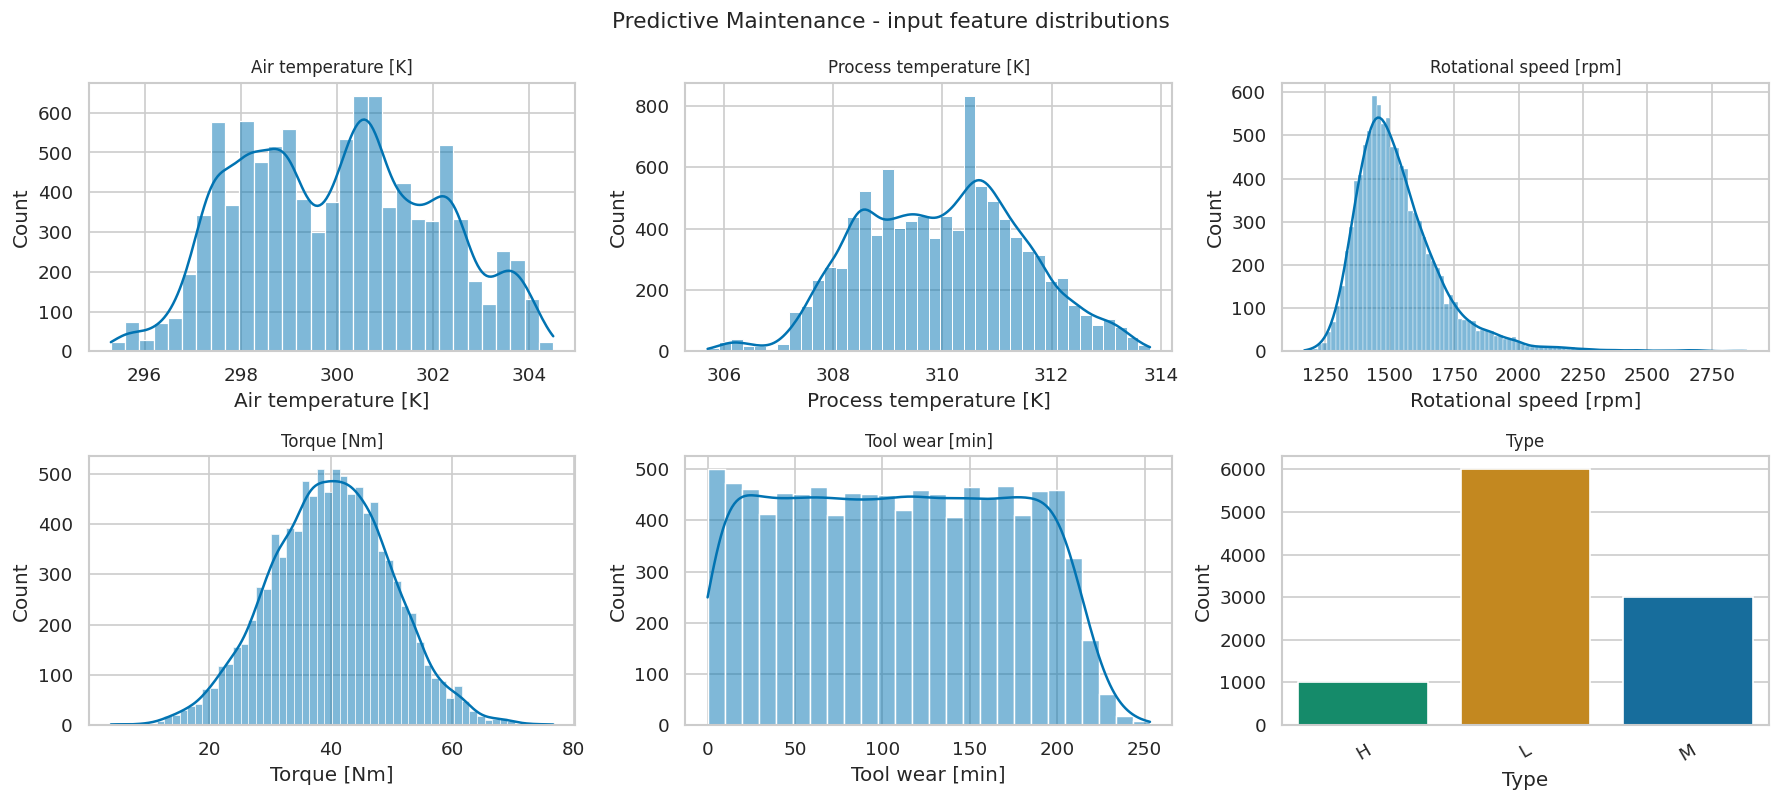

In [8]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### TEAM TO COMPLETE - Feature distributions
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Which features look approximately normal, and which are skewed or bounded?
> 2. Air and process temperature: what does their shape suggest about how this synthetic data was generated?
> 3. Does the Type category split the machines evenly?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

In [9]:
p = pl.correlation_heatmap(df, "Predictive Maintenance - correlation heatmap (numeric)",
                           "nb_clf_correlation_heatmap", "classification")

[fig] results/figures/classification/nb_clf_correlation_heatmap.png


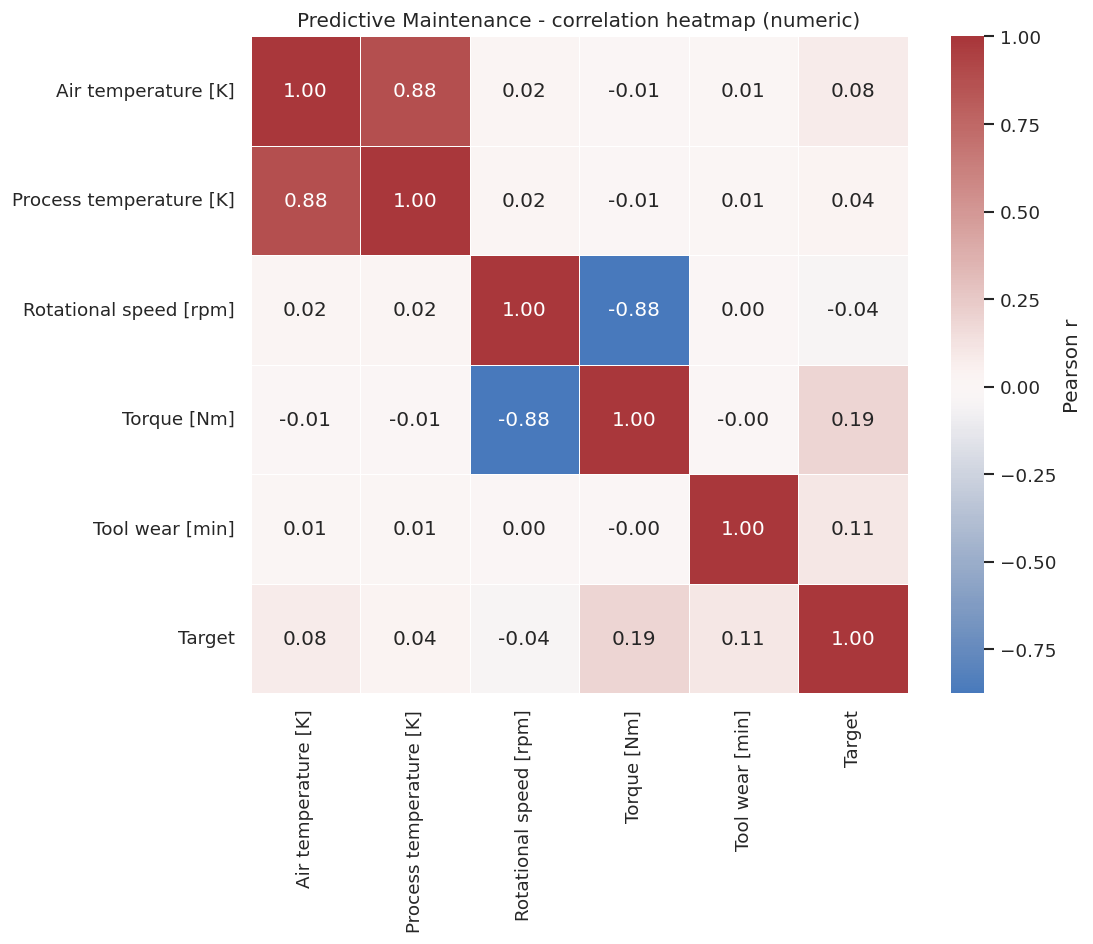

In [10]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [11]:
df.select_dtypes("number").corr().round(3)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
Air temperature [K],1.000,0.876,0.023,-0.014,0.014,0.083
Process temperature [K],0.876,1.000,0.019,-0.014,0.013,0.036
Rotational speed [rpm],0.023,0.019,1.000,-0.875,0.000,-0.044
Torque [Nm],-0.014,-0.014,-0.875,1.000,-0.003,0.191
Tool wear [min],0.014,0.013,0.000,-0.003,1.000,0.105
Target,0.083,0.036,-0.044,0.191,0.105,1.000


> ### TEAM TO COMPLETE - Correlation structure
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Two pairs of features are strongly related. Which pairs, and why physically?
> 2. Does any single feature correlate strongly with Target on its own? What does that imply about whether failure is a single-variable phenomenon?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

In [12]:
p = pl.target_distribution(df[TARGET], "Target distribution - machine failure",
                           "nb_clf_target_distribution", "classification",
                           discrete=True, class_names={0: CLS[0], 1: CLS[1]})

[fig] results/figures/classification/nb_clf_target_distribution.png


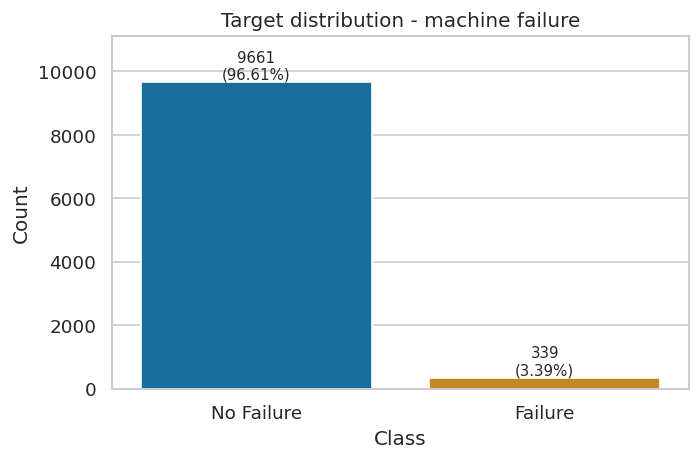

In [13]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### TEAM TO COMPLETE - Class imbalance
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. What fraction of rows are failures?
> 2. What accuracy would a model get by predicting 'No Failure' every single time?
> 3. Which metric should therefore lead your comparison, and why not accuracy?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

In [14]:
p = pl.feature_target_scatter(df, ["Torque [Nm]", "Rotational speed [rpm]"], TARGET,
                              "nb_clf_feature_target_scatter", "classification",
                              jitter=0.08,
                              title="Feature-target relationships (target jittered for readability)")

[fig] results/figures/classification/nb_clf_feature_target_scatter.png


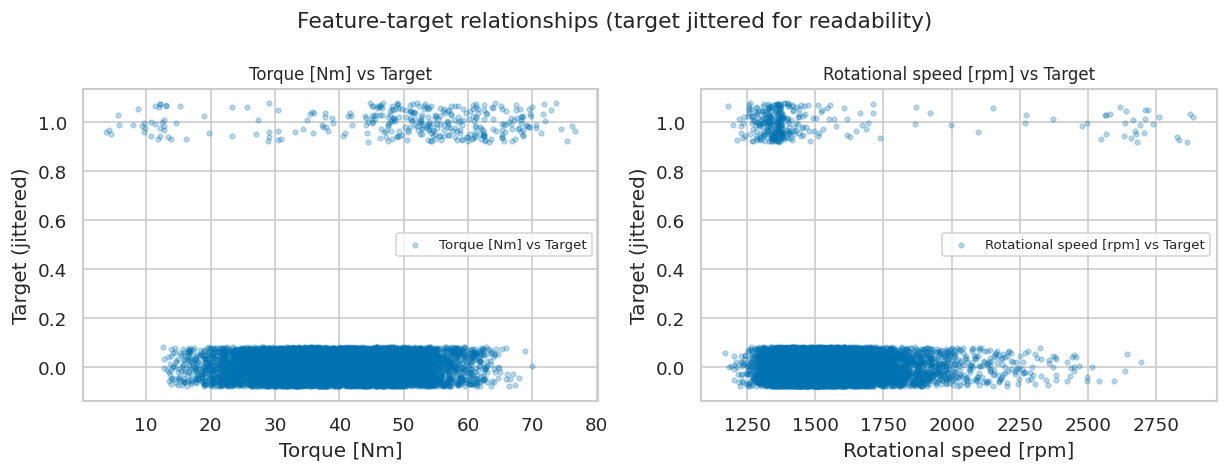

In [15]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [16]:
p = pl.grouped_box(df, ["Torque [Nm]", "Rotational speed [rpm]", "Tool wear [min]"],
                   TARGET, "nb_clf_feature_by_class", "classification",
                   class_names={0: CLS[0], 1: CLS[1]})

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: 

[fig] results/figures/classification/nb_clf_feature_by_class.png


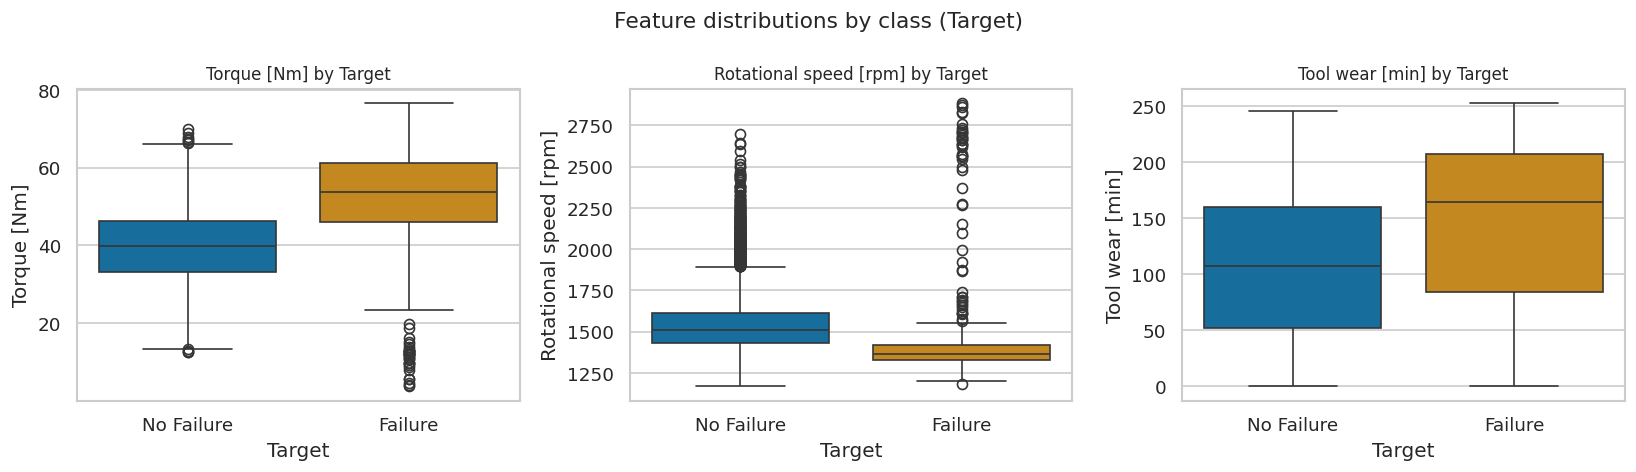

In [17]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [18]:
print("mean of each feature, by class:")
df.groupby(TARGET).mean(numeric_only=True).round(3).T

mean of each feature, by class:


Target,0,1
Air temperature [K],299.974,300.886
Process temperature [K],309.996,310.290
Rotational speed [rpm],1540.260,1496.487
Torque [Nm],39.630,50.168
Tool wear [min],106.694,143.782


> ### TEAM TO COMPLETE - Feature-target relationships
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. In which region of torque and rotational speed do failures concentrate?
> 2. Do the box plots separate the two classes on any single feature, or is failure an interaction between features?
> 3. What does that suggest about linear versus tree-based models here?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 3. Split, baseline and feature engineering  *(Rubric B1, B2, B3)*

**Stratified** 80:20. With only 3.4% positives, an unstratified split could give
train and test noticeably different failure rates and make the comparison unfair.

As in the regression notebook, all preprocessing lives inside each Pipeline, so
scalers and encoders are fitted on training data only and refitted per CV fold.

In [19]:
X_train, X_test, y_train, y_test = pp.split_supervised(df, TARGET, stratify=True)
print(f"\ntrain: {X_train.shape}   test: {X_test.shape}")
print("train failure rate:", round(y_train.mean() * 100, 3), "%")
print("test  failure rate:", round(y_test.mean() * 100, 3), "%")

[split] train=(8000, 6) test=(2000, 6) stratify=target

train: (8000, 6)   test: (2000, 6)
train failure rate: 3.388 %
test  failure rate: 3.4 %


In [20]:
baseline = ev.majority_class_baseline(y_train, y_test)
baseline

{'majority_class': 0,
 'baseline_accuracy': 0.966,
 'baseline_f1_weighted': 0.949293997965412,
 'test_class_counts': {0: 1932, 1: 68}}

> **Read the baseline before any model score.** Every model below must be judged
> against this number, not against zero.

In [21]:
fe.status("classification")

{'track': 'classification',
 'state': 'AWAITING TEAM INPUT',
 'rubric_B3': 'INCOMPLETE',
 'detail': 'No engineered feature registered; baseline pipeline executed.'}

> ### TEAM TO COMPLETE - Engineered feature (Q-CF1) - required for rubric B3
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Which physically meaningful quantity could you derive from the existing columns?
> 2. State your justification BEFORE measuring it.
> 3. After registering it and re-running, did failure recall improve? Report honestly.
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 4. The five Part A algorithms  *(Rubric D1, D2)*

**Metric conventions, stated once and used everywhere:**

* Precision and Recall are **binary**, with **failure (`Target == 1`) as the positive class**
* F1 is **weighted**, as the rubric mandates
* ROC-AUC uses `predict_proba` / `decision_function` - **never** hard predictions

**What each metric means here:**

| Metric | Plain meaning |
|---|---|
| Accuracy | share of all 2,000 test machines classified correctly |
| Precision (failure) | of the machines we called failures, how many really failed |
| Recall (failure) | of the machines that really failed, how many we caught |
| F1 (weighted) | harmonic mean of precision and recall, averaged over classes by size |
| ROC-AUC | probability the model scores a random failure above a random healthy machine |

In [22]:
from sklearn.metrics import confusion_matrix

results = {}     # model name -> metrics
fitted  = {}     # model name -> fitted Pipeline
cms     = {}     # model name -> confusion matrix

def record(name, model):
    """Evaluate on the held-out test set, print a readable report, store it."""
    y_pred = model.predict(X_test)
    y_score, how = ev._scores_for_auc(model, X_test)
    m = ev.classification_metrics(y_test, y_pred, y_score)
    m["AUC_source"] = how
    results[name] = m
    fitted[name] = model
    cm = confusion_matrix(y_test, y_pred)
    cms[name] = cm
    tn, fp, fn, tp = cm.ravel()
    print(f"{name}")
    print(f"  Accuracy          : {m['Accuracy']:.4f}   (baseline {baseline['baseline_accuracy']:.4f})")
    print(f"  Precision(failure): {m['Precision_failure']:.4f}")
    print(f"  Recall(failure)   : {m['Recall_failure']:.4f}")
    print(f"  F1 (weighted)     : {m['F1_weighted']:.4f}")
    print(f"  ROC-AUC           : {m['ROC_AUC']:.4f}   (from {how})")
    print(f"  confusion: correct-safe={tn}  false-alarms={fp}  MISSED={fn}  caught={tp}")
    return m

### 4.1 A1. Logistic Regression  [Part A, Review 1]

**What it is**

Despite the name, this is a classifier. It computes a weighted sum of the inputs, then squashes that number into a probability between 0 and 1 with the sigmoid function.

**How it works**

1. Compute z = weight1 x torque + weight2 x speed + ... + intercept.
2. Squash it: probability = 1 / (1 + e^-z). Large positive z gives a probability near 1; large negative gives near 0.
3. Find the weights that make the training labels most likely (maximum likelihood), by iterative optimisation.
4. To predict a class, compare the probability to a threshold - 0.5 by default.
5. The threshold is a CHOICE, not part of the model. Lowering it catches more failures at the cost of more false alarms.

**Settings you can tune**

C - the inverse of regularisation strength; class_weight='balanced' makes rare failures count more. We searched C in 0.01-10 and both weightings.

**Viva note** - Exponentiating a coefficient gives an ODDS RATIO: how much the odds of failure multiply per one standard deviation of that feature. See results/tables/classification_logreg_odds.csv.

In [23]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

model.fit(X_train, y_train)
record("A1. Logistic Regression", model)

A1. Logistic Regression
  Accuracy          : 0.9675   (baseline 0.9660)
  Precision(failure): 0.6364
  Recall(failure)   : 0.1029
  F1 (weighted)     : 0.9560
  ROC-AUC           : 0.8994   (from predict_proba)
  confusion: correct-safe=1928  false-alarms=4  MISSED=61  caught=7


{'Accuracy': 0.9675,
 'Precision_failure': 0.6363636363636364,
 'Recall_failure': 0.10294117647058823,
 'F1_weighted': 0.9560115444587566,
 'F1_failure': 0.17721518987341772,
 'ROC_AUC': 0.8993880160759956,
 'AUC_source': 'predict_proba'}

In [24]:
# --- ALGORITHM-SPECIFIC: odds ratios (PDF note: "interpret coefficients/odds")
from src.classification_models import odds_table
o = odds_table(model)
print("\n  Coefficients and odds ratios (per 1 standard deviation):")
print(o.to_string(index=False))


  Coefficients and odds ratios (per 1 standard deviation):
                feature  coefficient_log_odds  odds_ratio
            Torque [Nm]              2.722502   15.218355
 Rotational speed [rpm]              2.021327    7.548334
    Air temperature [K]              1.427572    4.168567
Process temperature [K]             -0.960367    0.382752
        Tool wear [min]              0.788159    2.199343
                 Type_L              0.376102    1.456596
                 Type_H             -0.284608    0.752309
                 Type_M             -0.105202    0.900142


### 4.2 A2. K-Nearest Neighbors  [Part A, Review 1]

**What it is**

Find the 5 most similar machines in the training data and take a majority vote on whether they failed.

**How it works**

1. Store the training rows. No model is fitted.
2. For a new machine, measure the distance to every training machine.
3. Keep the k closest.
4. Count their labels. The majority label wins.
5. The predicted probability is simply the fraction of those k neighbours that failed - which is why with k=5 the only possible probabilities are 0, 0.2, 0.4, 0.6, 0.8, 1.0.

**Settings you can tune**

n_neighbors (k) and the distance metric. We compared euclidean, manhattan and chebyshev.

**Viva note** - Coarse probabilities are why its ROC-AUC (0.8291) is the weakest in Part A even though its accuracy looks fine. AUC needs finely graded scores to rank cases; KNN with k=5 offers only six possible values.

In [25]:
from sklearn.neighbors import KNeighborsClassifier

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("model", KNeighborsClassifier(n_neighbors=5)),
])

model.fit(X_train, y_train)
record("A2. K-Nearest Neighbors", model)

A2. K-Nearest Neighbors
  Accuracy          : 0.9740   (baseline 0.9660)
  Precision(failure): 0.8333
  Recall(failure)   : 0.2941
  F1 (weighted)     : 0.9679
  ROC-AUC           : 0.8291   (from predict_proba)
  confusion: correct-safe=1928  false-alarms=4  MISSED=48  caught=20


{'Accuracy': 0.974,
 'Precision_failure': 0.8333333333333334,
 'Recall_failure': 0.29411764705882354,
 'F1_weighted': 0.9679289751234925,
 'F1_failure': 0.43478260869565216,
 'ROC_AUC': 0.8290859822189744,
 'AUC_source': 'predict_proba'}

In [26]:
# --- ALGORITHM-SPECIFIC: distance metrics (PDF note: "discuss distance metrics")
from src.classification_models import knn_distance_metric_comparison
print("\n  Distance metric comparison:")
print(knn_distance_metric_comparison(NUM, CAT, X_train, y_train,
                                     X_test, y_test).to_string(index=False))


  Distance metric comparison:


distance_metric  Accuracy  Precision_failure  Recall_failure  F1_weighted  ROC_AUC
      euclidean    0.9740           0.833333        0.294118     0.967929 0.829086
      manhattan    0.9735           0.826087        0.279412     0.967100 0.829756
      chebyshev    0.9710           0.777778        0.205882     0.962755 0.804017


### 4.3 A3. Gaussian Naive Bayes  [Part A, Review 1]

**What it is**

Uses Bayes' theorem to flip the question around. Instead of asking 'given these readings, will it fail?', it asks 'if a machine were failing, how likely are these readings?' - and combines that with how common failure is overall.

**How it works**

1. For each class separately, compute the mean and variance of every feature from the training data.
2. That gives a bell curve per feature per class.
3. For a new machine, read off how likely each of its readings is under each class's bell curve.
4. MULTIPLY those likelihoods together - this is the 'naive' step, and it assumes the features are independent given the class.
5. Multiply by the class's base rate (3.39% for failure) and pick whichever class scores higher.

**Settings you can tune**

Effectively none. GaussianNB is parameter-free; it just measures means and variances.

**Viva note** - The independence assumption is the exam question. Air temperature and process temperature are strongly correlated in our data - physically, the process is heated by its surroundings. Naive Bayes multiplies their evidence as if they were unrelated, so it double-counts one fact. Its F1 of 0.9506 is the lowest in Part A, and that is why.

In [27]:
from sklearn.naive_bayes import GaussianNB

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("model", GaussianNB()),
])

model.fit(X_train, y_train)
record("A3. Gaussian Naive Bayes", model)

A3. Gaussian Naive Bayes
  Accuracy          : 0.9580   (baseline 0.9660)
  Precision(failure): 0.2500
  Recall(failure)   : 0.1176
  F1 (weighted)     : 0.9506
  ROC-AUC           : 0.8468   (from predict_proba)
  confusion: correct-safe=1908  false-alarms=24  MISSED=60  caught=8


{'Accuracy': 0.958,
 'Precision_failure': 0.25,
 'Recall_failure': 0.11764705882352941,
 'F1_weighted': 0.9506338461538462,
 'F1_failure': 0.16,
 'ROC_AUC': 0.8468137254901961,
 'AUC_source': 'predict_proba'}

### 4.4 A4. Decision Tree Classifier  [Part A, Review 1]

**What it is**

A flowchart of yes/no questions about the sensor readings, ending in a verdict of fail or no-fail.

**How it works**

1. Begin with all 8,000 training machines in one group.
2. Try every feature and cut point, and score each by how much it purifies the groups - measured by Gini impurity.
3. A perfect split puts all failures on one side and all healthy machines on the other.
4. Take the best split, then repeat on each resulting branch.
5. Stop at max_depth. Each leaf predicts the majority class of its training members, and the probability is the class proportion in that leaf.

**Settings you can tune**

max_depth, min_samples_leaf, class_weight. We searched depth 3/5/8/12/None.

**Viva note** - This is the only Part A model you can literally read. results/figures/classification/clf_decision_tree.png shows the top 3 levels - point at the first split and state the physical rule it found. It is also our best Part A model, so the rule it learned is worth quoting.

In [28]:
from sklearn.tree import DecisionTreeClassifier

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=False)),
    ("model", DecisionTreeClassifier(max_depth=6, random_state=42)),
])

model.fit(X_train, y_train)
record("A4. Decision Tree Classifier", model)

A4. Decision Tree Classifier
  Accuracy          : 0.9755   (baseline 0.9660)
  Precision(failure): 0.7879
  Recall(failure)   : 0.3824
  F1 (weighted)     : 0.9714
  ROC-AUC           : 0.9219   (from predict_proba)
  confusion: correct-safe=1925  false-alarms=7  MISSED=42  caught=26


{'Accuracy': 0.9755,
 'Precision_failure': 0.7878787878787878,
 'Recall_failure': 0.38235294117647056,
 'F1_weighted': 0.9713649145884067,
 'F1_failure': 0.5148514851485149,
 'ROC_AUC': 0.9218540677140421,
 'AUC_source': 'predict_proba'}

In [29]:
# --- ALGORITHM-SPECIFIC: draw the tree (PDF note: "visualise the tree")
from src import plotting as pl
p = pl.decision_tree_figure(model.named_steps["model"],
                            model.named_steps["prep"].get_feature_names_out(),
                            ["No Failure", "Failure"],
                            "example_decision_tree", "classification", max_depth=3)
print(f"\n  Tree diagram saved to {p}")

[fig] results/figures/classification/example_decision_tree.png

  Tree diagram saved to /mnt/attach/outputs/23CSE301-ML-Review1/results/figures/classification/example_decision_tree.png


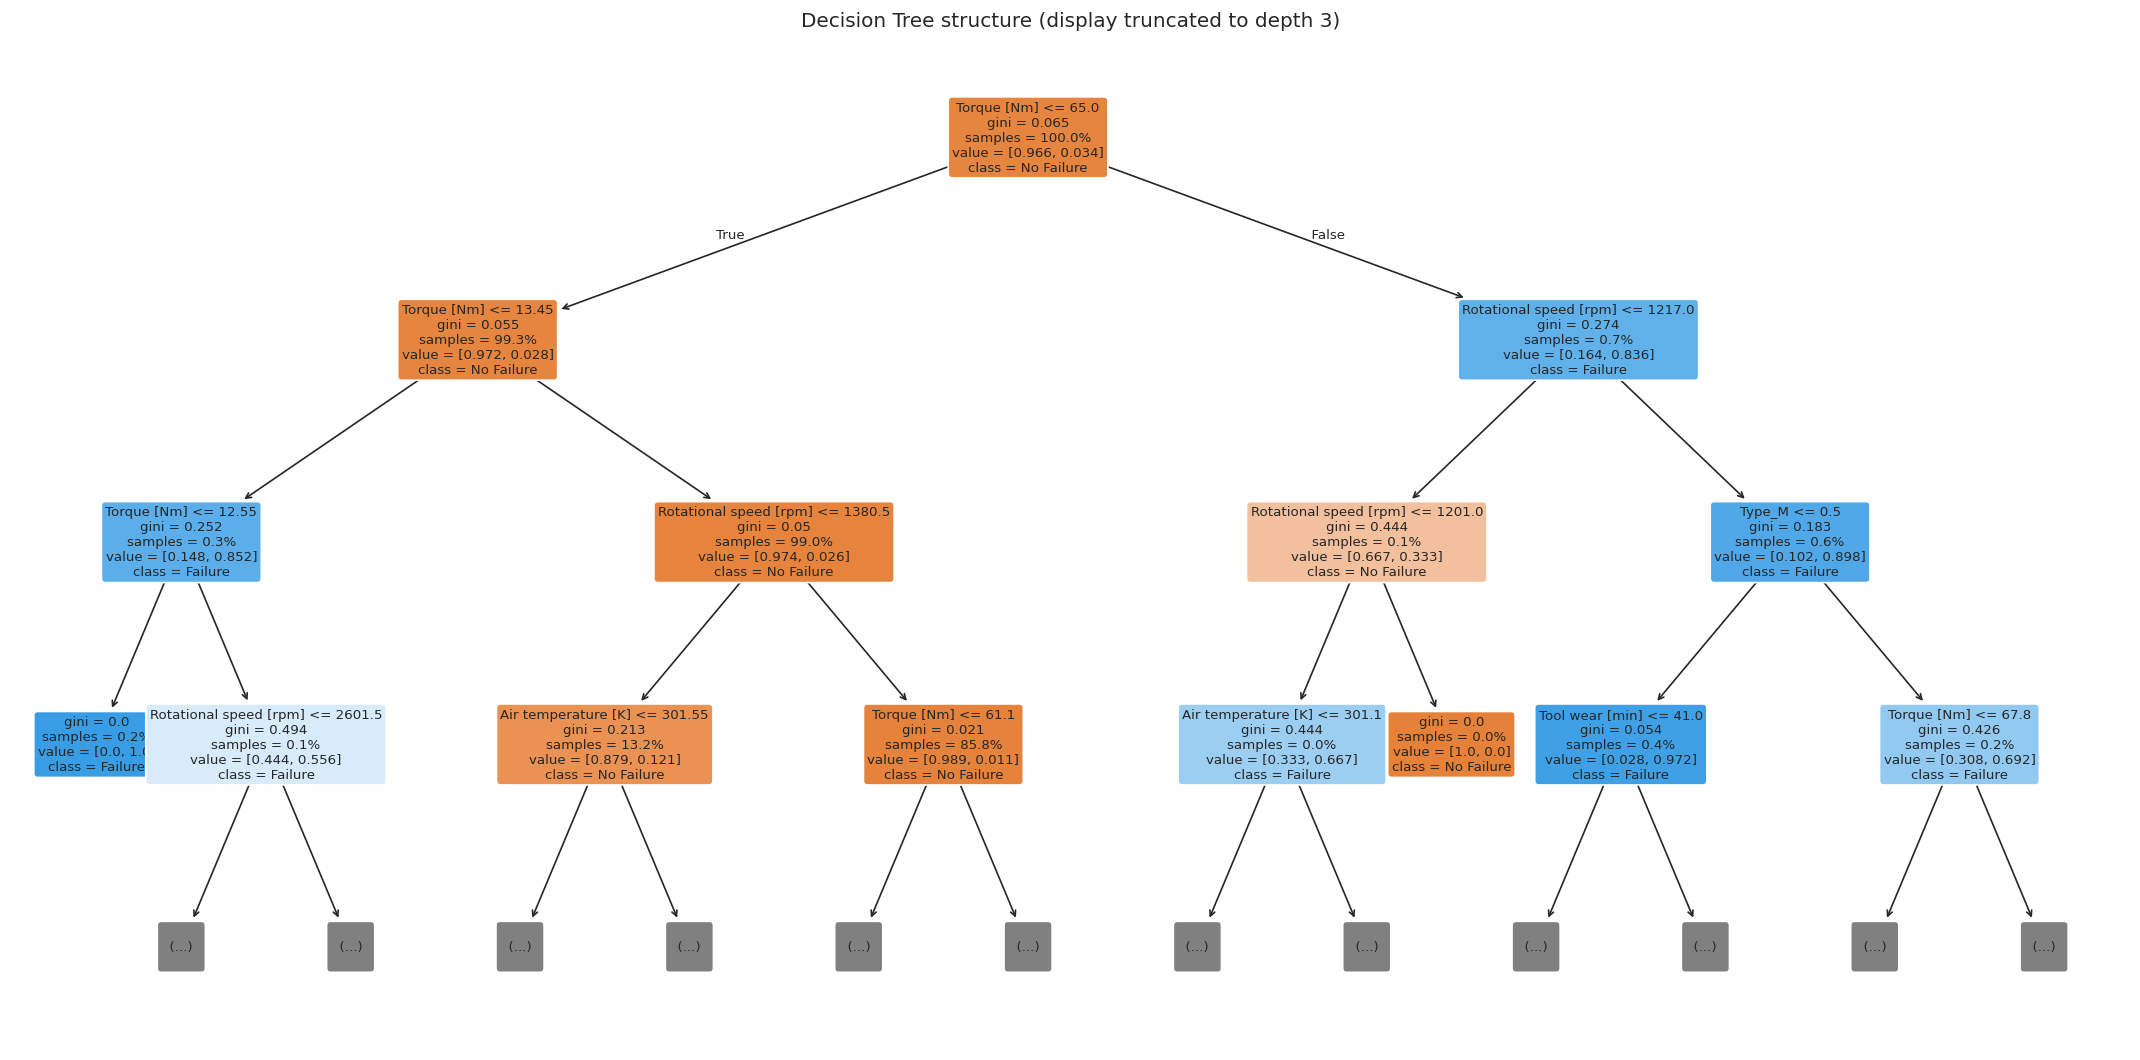

In [30]:
from IPython.display import Image, display
display(Image(filename=str(p)))

### 4.5 A5. Support Vector Classifier (SVC)  [Part A, Review 1]

**What it is**

Draws the boundary between failing and healthy machines that leaves the widest possible empty margin on both sides.

**How it works**

1. Look for a surface separating the two classes.
2. Among all surfaces that separate them, prefer the one with the largest gap to the nearest point on each side.
3. Allow some points to sit inside the margin or on the wrong side, penalised by C.
4. The RBF kernel measures similarity by distance, letting the boundary curve without computing curved coordinates explicitly.
5. Only the points nearest the boundary - the support vectors - define it. Moving a far-away point changes nothing.

**Settings you can tune**

C (low C means a wide, forgiving margin; high C means fit the training data hard) and kernel. probability=True is needed for ROC-AUC and costs extra fitting time.

**Viva note** - Precision 0.875 with Recall 0.2059 - it is very careful. When it cries failure it is almost always right, but it stays quiet about 54 of the 68 real failures. Wide-margin fitting on an imbalanced dataset pushes the boundary toward the majority class.

In [31]:
from sklearn.svm import SVC

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("model", SVC(C=1.0, kernel='rbf', probability=True, random_state=42)),
])

model.fit(X_train, y_train)
record("A5. Support Vector Classifier (SVC)", model)

A5. Support Vector Classifier (SVC)
  Accuracy          : 0.9720   (baseline 0.9660)
  Precision(failure): 0.8750
  Recall(failure)   : 0.2059
  F1 (weighted)     : 0.9635
  ROC-AUC           : 0.9468   (from predict_proba)
  confusion: correct-safe=1930  false-alarms=2  MISSED=54  caught=14


{'Accuracy': 0.972,
 'Precision_failure': 0.875,
 'Recall_failure': 0.20588235294117646,
 'F1_weighted': 0.9635192373169902,
 'F1_failure': 0.3333333333333333,
 'ROC_AUC': 0.9468167701863354,
 'AUC_source': 'predict_proba'}

## 5. Part A comparison  *(Rubric D2 - Review 1 deliverable)*

One table, all five Part A algorithms, same dataset and same held-out split.

In [32]:
cols = ["Model", "Accuracy", "Precision_failure", "Recall_failure",
        "F1_weighted", "ROC_AUC", "AUC_source"]
table = (pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
         .sort_values("F1_weighted", ascending=False).reset_index(drop=True))[cols]
table.index = table.index + 1
table.index.name = "Rank"
print(f"{len(table)} models | majority-class baseline: "
      f"accuracy {baseline['baseline_accuracy']:.4f}, "
      f"weighted F1 {baseline['baseline_f1_weighted']:.4f}\n")
table

5 models | majority-class baseline: accuracy 0.9660, weighted F1 0.9493



,Model,Accuracy,Precision_failure,Recall_failure,F1_weighted,ROC_AUC,AUC_source
Rank,,,,,,,
1,A4. Decision Tree Classifier,0.9755,0.787879,0.382353,0.971365,0.921854,predict_proba
2,A2. K-Nearest Neighbors,0.974,0.833333,0.294118,0.967929,0.829086,predict_proba
3,A5. Support Vector Classifier (SVC),0.972,0.875,0.205882,0.963519,0.946817,predict_proba
4,A1. Logistic Regression,0.9675,0.636364,0.102941,0.956012,0.899388,predict_proba
5,A3. Gaussian Naive Bayes,0.958,0.25,0.117647,0.950634,0.846814,predict_proba


In [33]:
p = pl.model_comparison_bar(table, "F1_weighted",
                            "Part A classifiers ranked by weighted F1",
                            "nb_clf_model_comparison", "classification")

[fig] results/figures/classification/nb_clf_model_comparison.png


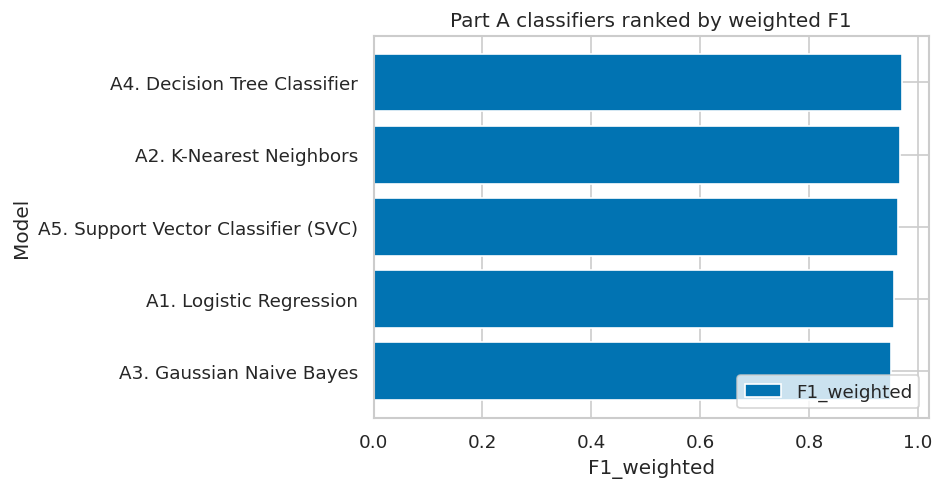

In [34]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [35]:
p = pl.confusion_grid(cms, CLS, "Part A confusion matrices (held-out test set)",
                      "nb_clf_confusion_partA", "classification")

[fig] results/figures/classification/nb_clf_confusion_partA.png


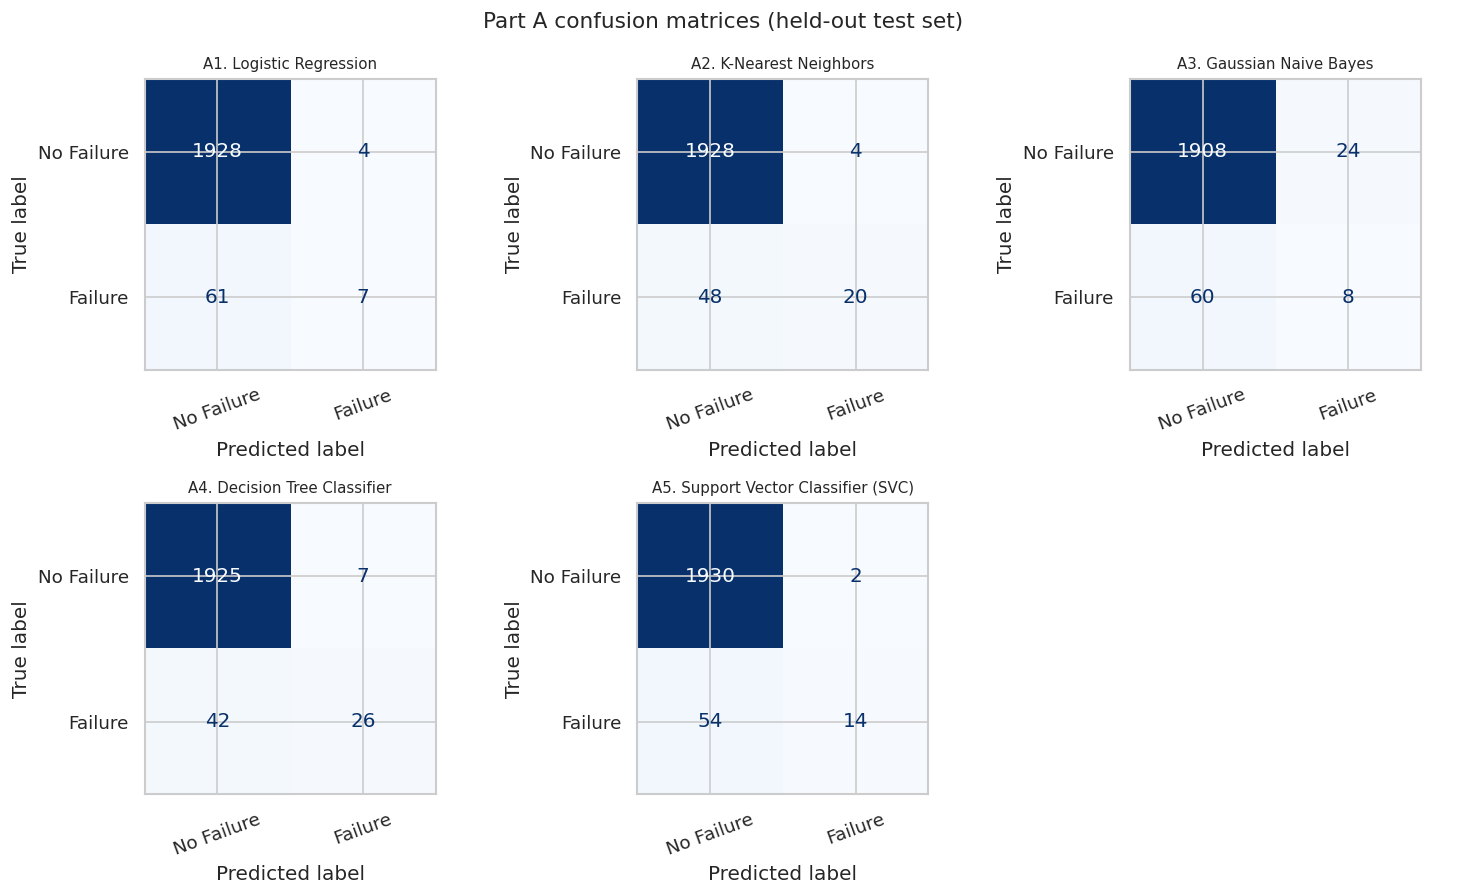

In [36]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [37]:
p = pl.roc_curves(fitted, X_test, y_test,
                  "ROC curves (probability / decision scores, not hard labels)",
                  "nb_clf_roc_curves", "classification")

[fig] results/figures/classification/nb_clf_roc_curves.png


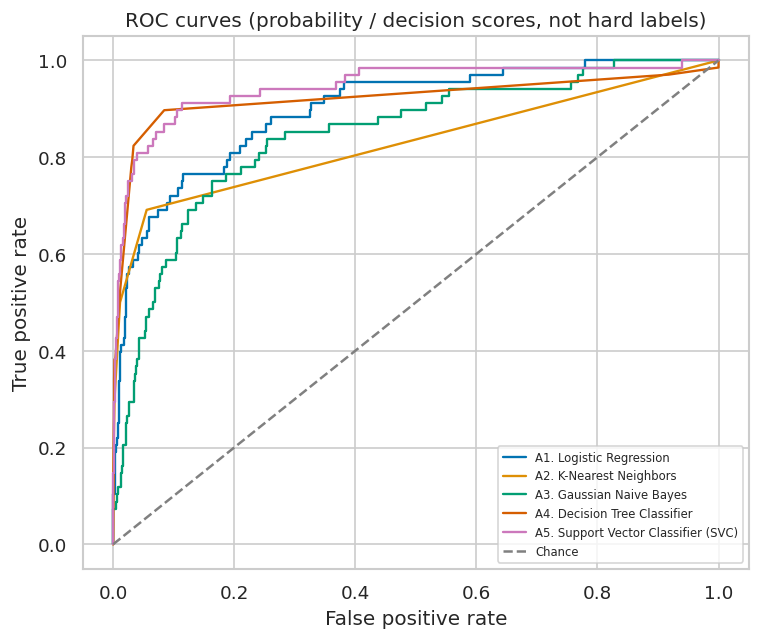

In [38]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### TEAM TO COMPLETE - Part A comparison (Review 1 deliverable)
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Rank the five models on weighted F1, then on failure recall. Does the ranking change?
> 2. Look at the confusion matrices: which models achieve high accuracy mainly by rarely predicting failure at all?
> 3. In a maintenance setting, which error costs more - a missed failure or a false alarm? Which model does your answer favour?
> 4. Accuracy spans a narrow range while failure recall spans a wide one. What does that tell you?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 6. Cross-validation and tuning

Leading models are nominated on **training-side** cross-validation; the
held-out test set plays no part in selection.

In [39]:
cv_all = ev.cv_scores(fitted, X_train, y_train, scoring="f1_weighted")
cv_all.drop(columns="fold_scores").sort_values("CV_mean", ascending=False)

  A1. Logistic Regression            f1_weighted CV = 0.9618 (+/- 0.0035)
  A2. K-Nearest Neighbors            f1_weighted CV = 0.9679 (+/- 0.0024)


  A3. Gaussian Naive Bayes           f1_weighted CV = 0.9553 (+/- 0.0034)
  A4. Decision Tree Classifier       f1_weighted CV = 0.9748 (+/- 0.0017)


  A5. Support Vector Classifier (SVC) f1_weighted CV = 0.9668 (+/- 0.0018)


,Model,scoring,folds,CV_mean,CV_std
3,A4. Decision Tree Classifier,f1_weighted,5,0.974801,0.001737
1,A2. K-Nearest Neighbors,f1_weighted,5,0.967863,0.002429
4,A5. Support Vector Classifier (SVC),f1_weighted,5,0.966767,0.001767
0,A1. Logistic Regression,f1_weighted,5,0.961765,0.003476
2,A3. Gaussian Naive Bayes,f1_weighted,5,0.955302,0.003372


In [40]:
from src import classification_models as cm

leaders = cv_all.sort_values("CV_mean", ascending=False)["Model"].head(2).tolist()
print("leaders selected on TRAINING cross-validation:", leaders)

rows, tuned = {}, {}
for name in leaders:
    if name not in cm.PARAM_GRIDS:
        continue
    before_cv = float(cv_all.loc[cv_all["Model"] == name, "CV_mean"].iloc[0])
    before = table[table["Model"] == name].iloc[0]
    gs = cm.tune(name, fitted[name], X_train, y_train)
    score, _ = ev._scores_for_auc(gs.best_estimator_, X_test)
    after = ev.classification_metrics(y_test, gs.best_estimator_.predict(X_test), score)
    rows[name] = {
        "best_params": gs.best_params_,
        "CV_F1w_before": round(before_cv, 5),
        "CV_F1w_after": round(gs.best_score_, 5),
        "HeldOut_F1w_before": round(float(before["F1_weighted"]), 5),
        "HeldOut_F1w_after": round(after["F1_weighted"], 5),
        "Recall_fail_before": round(float(before["Recall_failure"]), 5),
        "Recall_fail_after": round(after["Recall_failure"], 5),
        "improved_on_CV": bool(gs.best_score_ > before_cv),
    }
    tuned[name] = gs.best_estimator_
pd.DataFrame(rows).T

leaders selected on TRAINING cross-validation: ['A4. Decision Tree Classifier', 'A2. K-Nearest Neighbors']


  [tuned] A4. Decision Tree Classifier: best f1_weighted=0.9817 params={'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_leaf': 5}


  [tuned] A2. K-Nearest Neighbors: best f1_weighted=0.9691 params={'model__n_neighbors': 3, 'model__weights': 'uniform'}


,best_params,CV_F1w_before,CV_F1w_after,HeldOut_F1w_before,HeldOut_F1w_after,Recall_fail_before,Recall_fail_after,improved_on_CV
A4. Decision Tree Classifier,"{'model__class_weight': None, 'model__max_dept...",0.9748,0.98168,0.97136,0.98421,0.38235,0.73529,True
A2. K-Nearest Neighbors,"{'model__n_neighbors': 3, 'model__weights': 'u...",0.96786,0.96912,0.96793,0.96631,0.29412,0.30882,True


> ### TEAM TO COMPLETE - Final model selection
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Which model do you select as final, and which metric drove the decision?
> 2. Did tuning improve at least one metric? Quote the before/after numbers - and if it did not, say so.
> 3. Does your chosen model trade failure recall for accuracy? Is that trade acceptable for the use case?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 7. Classification (Part A) conclusion

> ### TEAM TO COMPLETE - Classification conclusion
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Summarise Part A: problem -> data -> method -> result -> conclusion.
> 2. What is the single most important caveat a reader should keep in mind (imbalance? synthetic data? threshold choice?)
> 3. If this were deployed on a real production line, what would you monitor?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*